In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

crime = pd.read_csv("data/cleaned_crime_long.csv", parse_dates=["Date"])

print(crime.shape)

(195175, 7)


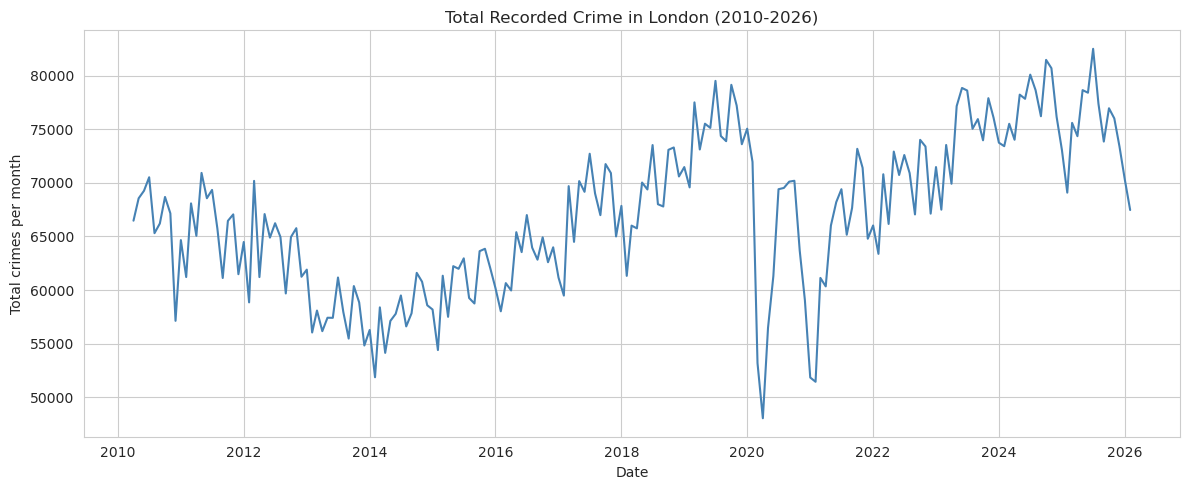

In [2]:
import os
os.makedirs("figures", exist_ok=True)

london_monthly = crime.groupby("Date")["CrimeCount"].sum()

plt.figure(figsize=(12, 5))
plt.plot(london_monthly.index, london_monthly.values, color="steelblue")
plt.title("Total Recorded Crime in London (2010-2026)")
plt.xlabel("Date")
plt.ylabel("Total crimes per month")
plt.tight_layout()
plt.savefig("figures/01_london_crime_trend.png", dpi=150)
plt.show()

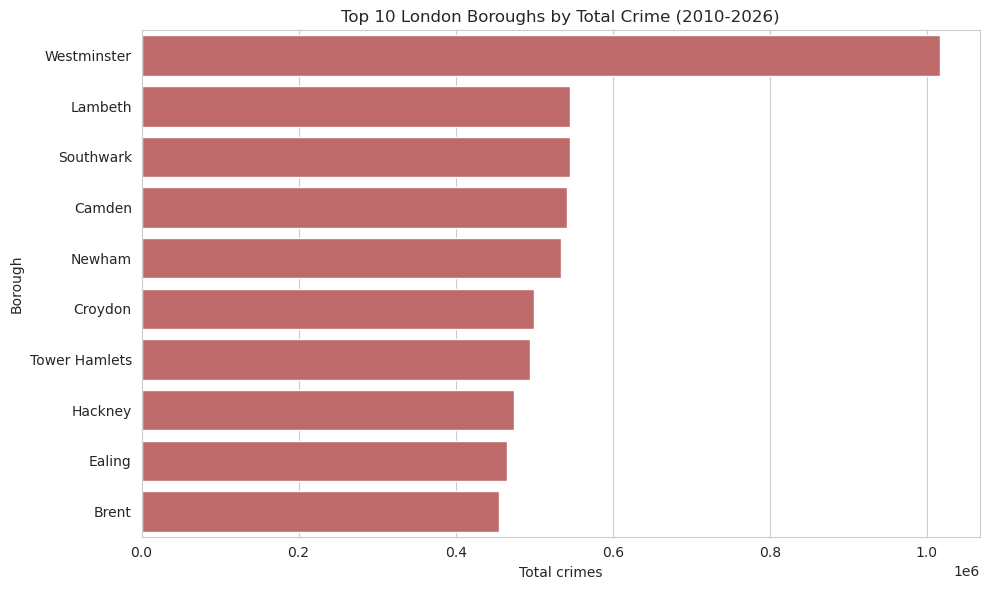

In [3]:
top_boroughs = crime.groupby("Borough")["CrimeCount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_boroughs.values, y=top_boroughs.index, color="indianred")
plt.title("Top 10 London Boroughs by Total Crime (2010-2026)")
plt.xlabel("Total crimes")
plt.ylabel("Borough")
plt.tight_layout()
plt.savefig("figures/02_top10_boroughs.png", dpi=150)
plt.show()

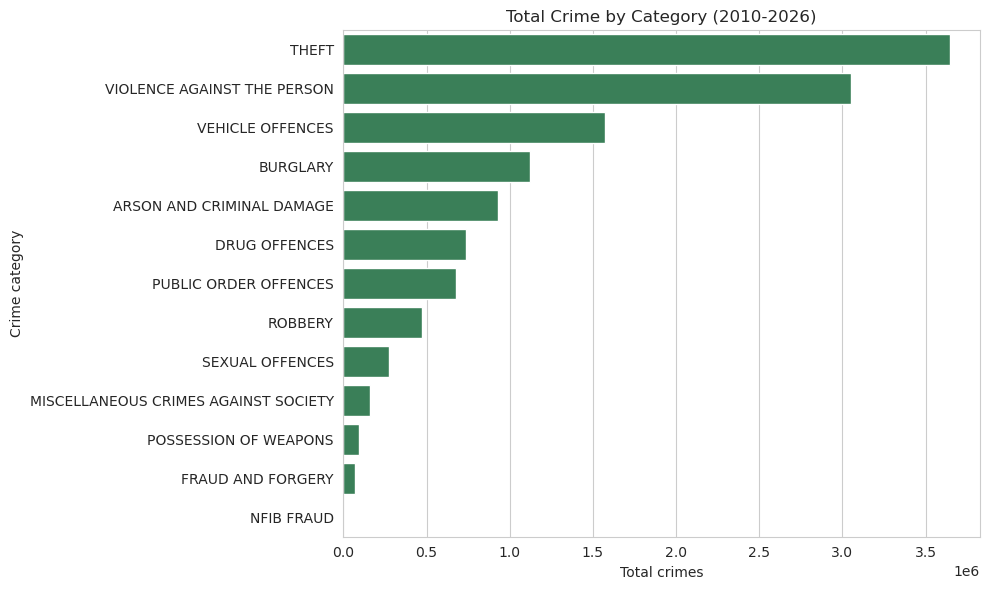

In [4]:
category_totals = crime.groupby("MajorCategory")["CrimeCount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_totals.values, y=category_totals.index, color="seagreen")
plt.title("Total Crime by Category (2010-2026)")
plt.xlabel("Total crimes")
plt.ylabel("Crime category")
plt.tight_layout()
plt.savefig("figures/03_crime_by_category.png", dpi=150)
plt.show()

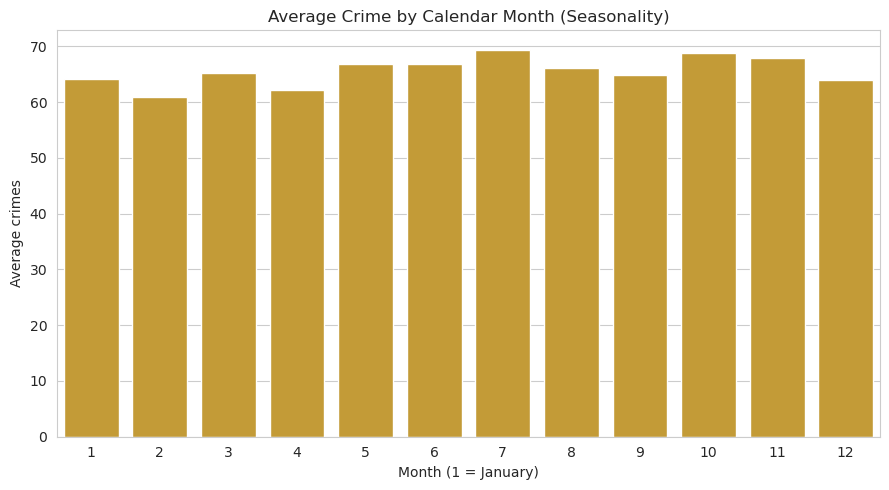

In [5]:
seasonal = crime.groupby("Month")["CrimeCount"].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=seasonal.index, y=seasonal.values, color="goldenrod")
plt.title("Average Crime by Calendar Month (Seasonality)")
plt.xlabel("Month (1 = January)")
plt.ylabel("Average crimes")
plt.tight_layout()
plt.savefig("figures/04_seasonality.png", dpi=150)
plt.show()

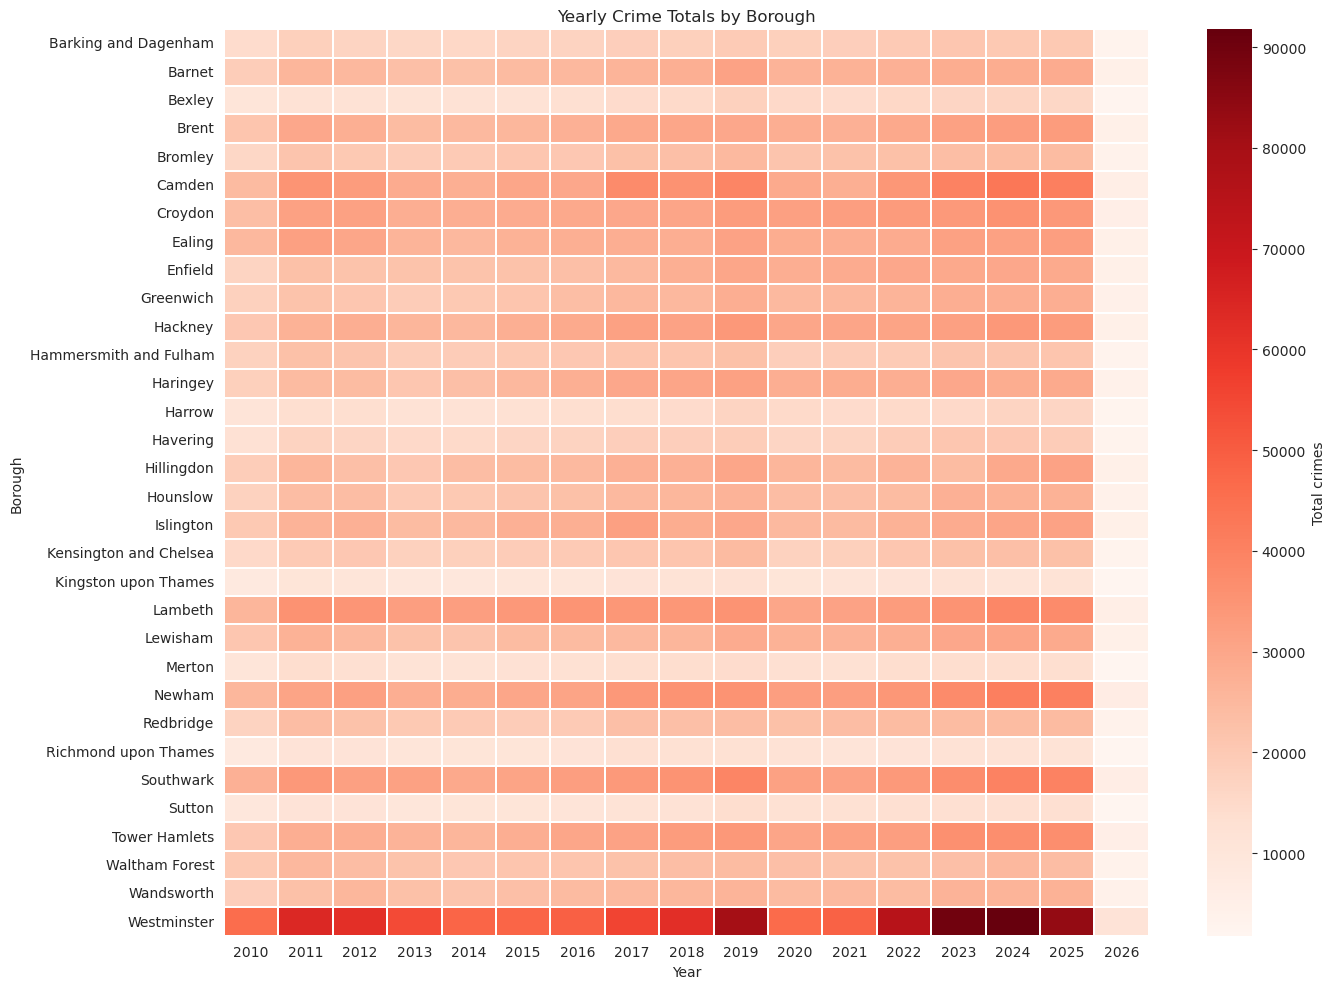

In [6]:
yearly_borough = crime.groupby(["Borough", "Year"])["CrimeCount"].sum().reset_index()
heatmap_data = yearly_borough.pivot(index="Borough", columns="Year", values="CrimeCount")

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="Reds", linewidths=0.3, cbar_kws={"label": "Total crimes"})
plt.title("Yearly Crime Totals by Borough")
plt.xlabel("Year")
plt.ylabel("Borough")
plt.tight_layout()
plt.savefig("figures/05_borough_year_heatmap.png", dpi=150)
plt.show()